In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

df = pd.read_csv('../Data/data_Denison_2018.csv')
df['Correct'] = (df['Stimulus'] == df['Response']).astype(int)

att_labels = {1: 'Valid', 2: 'Neutral', 3: 'Invalid'}
df['Attention_label'] = df['Attention'].map(att_labels)

df.head()

Matplotlib is building the font cache; this may take a moment.


,Subj_idx,Stimulus,Response,Confidence,RT_decConf,Attention,Orientation,Correct,Attention_label
0,1,1,1,1,0.276235,1,0.224658,1,Valid
1,1,2,1,2,1.754866,2,-6.965246,0,Neutral
2,1,2,2,2,1.232476,1,-8.439767,1,Valid
3,1,2,2,3,1.325371,1,-11.007351,1,Valid
4,1,1,1,2,1.165190,2,-2.968357,1,Neutral


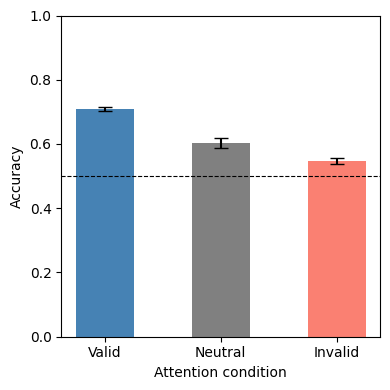

In [2]:
# Per-subject accuracy by attention condition
subj_acc = df.groupby(['Subj_idx', 'Attention'])['Correct'].mean().reset_index()

att_order = [1, 2, 3]
means = [subj_acc[subj_acc['Attention'] == a]['Correct'].mean() for a in att_order]
sems  = [subj_acc[subj_acc['Attention'] == a]['Correct'].sem()  for a in att_order]

fig, ax = plt.subplots(figsize=(4, 4))
ax.bar([1, 2, 3], means, yerr=sems, capsize=5, color=['steelblue', 'gray', 'salmon'], width=0.5)
ax.set_xticks([1, 2, 3])
ax.set_xticklabels(['Valid', 'Neutral', 'Invalid'])
ax.set_xlabel('Attention condition')
ax.set_ylabel('Accuracy')
ax.set_ylim(0, 1)
ax.axhline(0.5, color='k', linestyle='--', linewidth=0.8)
plt.tight_layout()
plt.show()

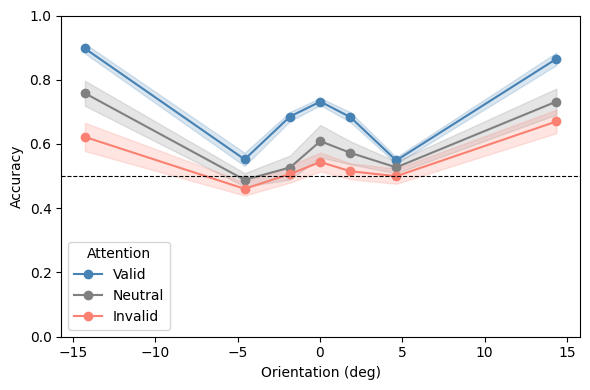

In [5]:
n_bins = 7
df['OriBin'] = pd.qcut(df['Orientation'], q=n_bins, duplicates='drop')
bin_centers = df.groupby('OriBin', observed=True)['Orientation'].mean()

# Per-subject mean accuracy per orientation bin x attention
subj_ori_acc = df.groupby(['Subj_idx', 'OriBin', 'Attention'], observed=True)['Correct'].mean().reset_index()

att_colors = {1: 'steelblue', 2: 'gray', 3: 'salmon'}

fig, ax = plt.subplots(figsize=(6, 4))
for att, label in att_labels.items():
    grp = subj_ori_acc[subj_ori_acc['Attention'] == att]
    stats = grp.groupby('OriBin', observed=True)['Correct'].agg(['mean', 'sem'])
    xs = bin_centers.values
    ax.plot(xs, stats['mean'].values, marker='o', label=label, color=att_colors[att])
    ax.fill_between(xs,
                    stats['mean'].values - stats['sem'].values,
                    stats['mean'].values + stats['sem'].values,
                    alpha=0.2, color=att_colors[att])

ax.axhline(0.5, color='k', linestyle='--', linewidth=0.8)
ax.set_xlabel('Orientation (deg)')
ax.set_ylabel('Accuracy')
ax.set_ylim(0, 1)
ax.legend(title='Attention')
plt.tight_layout()
plt.show()

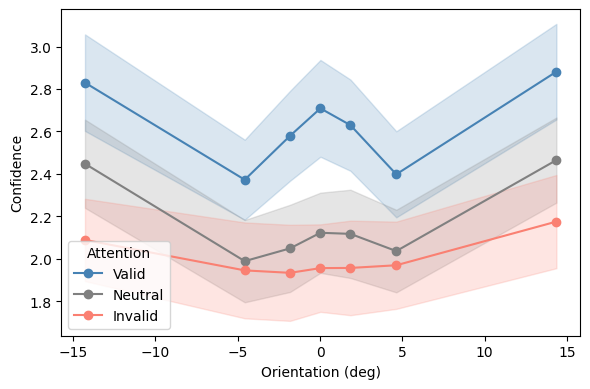

In [6]:
subj_ori_conf = df.groupby(['Subj_idx', 'OriBin', 'Attention'], observed=True)['Confidence'].mean().reset_index()

fig, ax = plt.subplots(figsize=(6, 4))
for att, label in att_labels.items():
    grp = subj_ori_conf[subj_ori_conf['Attention'] == att]
    stats = grp.groupby('OriBin', observed=True)['Confidence'].agg(['mean', 'sem'])
    xs = bin_centers.values
    ax.plot(xs, stats['mean'].values, marker='o', label=label, color=att_colors[att])
    ax.fill_between(xs,
                    stats['mean'].values - stats['sem'].values,
                    stats['mean'].values + stats['sem'].values,
                    alpha=0.2, color=att_colors[att])

ax.set_xlabel('Orientation (deg)')
ax.set_ylabel('Confidence')
ax.legend(title='Attention')
plt.tight_layout()
plt.show()

## Serial dependence analysis

In [9]:
# Create lagged variables within each subject (shift within subject groups)
df = df.sort_values(['Subj_idx']).copy()
for col in ['Stimulus', 'Response', 'Confidence', 'Attention', 'Orientation']:
    df[f'prev_{col}'] = df.groupby('Subj_idx')[col].shift(1)

# Drop first trial of each subject (no valid previous trial)
df_sd = df.dropna(subset=['prev_Stimulus']).copy()
df_sd['prev_Stimulus'] = df_sd['prev_Stimulus'].astype(int)
df_sd['prev_Response'] = df_sd['prev_Response'].astype(int)

# Serial choice bias: did current response match previous stimulus?
df_sd['choice_bias'] = (df_sd['Response'] == df_sd['prev_Response']).astype(int)

print(f"Trials for SD analysis: {len(df_sd)}")
df_sd[['Stimulus','Response','prev_Response','choice_bias','Attention']].head(8)

Trials for SD analysis: 24612


,Stimulus,Response,prev_Response,choice_bias,Attention
1079,1,1,1,1,2
2,2,2,1,0,1
3,2,2,2,1,1
4,1,1,2,0,2
5,1,1,1,1,1
6,2,1,1,1,3
7,1,1,1,1,3
8,2,1,1,1,1


## Serial dependence for choice as a function of attention

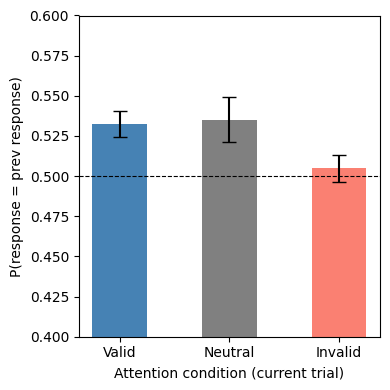

In [10]:
# Serial dependence in choice: P(response == prev_stimulus) by attention condition
subj_cb = df_sd.groupby(['Subj_idx', 'Attention'])['choice_bias'].mean().reset_index()

means = [subj_cb[subj_cb['Attention'] == a]['choice_bias'].mean() for a in att_order]
sems  = [subj_cb[subj_cb['Attention'] == a]['choice_bias'].sem()  for a in att_order]

fig, ax = plt.subplots(figsize=(4, 4))
ax.bar([1, 2, 3], means, yerr=sems, capsize=5,
       color=['steelblue', 'gray', 'salmon'], width=0.5)
ax.axhline(0.5, color='k', linestyle='--', linewidth=0.8, label='No bias')
ax.set_xticks([1, 2, 3])
ax.set_xticklabels(['Valid', 'Neutral', 'Invalid'])
ax.set_xlabel('Attention condition (current trial)')
ax.set_ylabel('P(response = prev response)')
ax.set_ylim(0.4, 0.6)
plt.tight_layout()
plt.show()

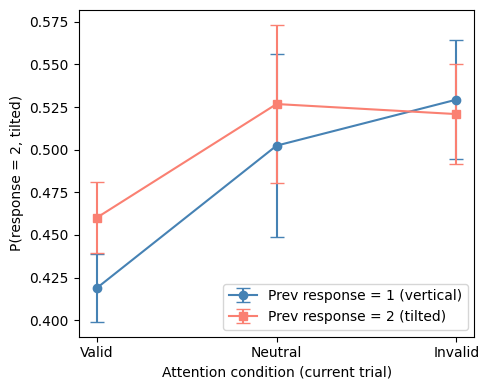

In [13]:
df_sd['resp2'] = (df_sd['Response'] == 2).astype(int)

subj_resp2 = df_sd.groupby(['Subj_idx', 'Attention', 'prev_Response'])['resp2'].mean().reset_index()

prev_resp_styles = {1: ('vertical', 'o', 'steelblue'), 2: ('tilted', 's', 'salmon')}

fig, ax = plt.subplots(figsize=(5, 4))
for prev_r, (label, marker, color) in prev_resp_styles.items():
    grp = subj_resp2[subj_resp2['prev_Response'] == prev_r]
    stats = grp.groupby('Attention')['resp2'].agg(['mean', 'sem'])
    xs = [1, 2, 3]
    ax.errorbar(xs, stats['mean'].values, yerr=stats['sem'].values,
                marker=marker, color=color, capsize=5, linewidth=1.5,
                label=f'Prev response = {prev_r} ({label})')

ax.set_xticks([1, 2, 3])
ax.set_xticklabels(['Valid', 'Neutral', 'Invalid'])
ax.set_xlabel('Attention condition (current trial)')
ax.set_ylabel('P(response = 2, tilted)')
ax.legend()
plt.tight_layout()
plt.show()

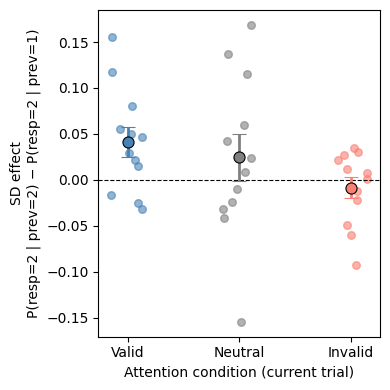

In [14]:
# SD effect per subject = P(resp=2 | prev=2) - P(resp=2 | prev=1)
pivot = subj_resp2.pivot_table(index=['Subj_idx', 'Attention'], columns='prev_Response', values='resp2').reset_index()
pivot.columns.name = None
pivot = pivot.rename(columns={1: 'prev1', 2: 'prev2'})
pivot['sd_effect'] = pivot['prev2'] - pivot['prev1']

rng = np.random.default_rng(0)
jitter = 0.15

fig, ax = plt.subplots(figsize=(4, 4))
for att in att_order:
    grp = pivot[pivot['Attention'] == att]['sd_effect']
    x = att
    # Individual points
    xs_jit = rng.uniform(x - jitter, x + jitter, size=len(grp))
    ax.scatter(xs_jit, grp.values, color=att_colors[att], alpha=0.6, s=30, zorder=2)
    # Group mean ± SEM
    ax.errorbar(x, grp.mean(), yerr=grp.sem(), color=att_colors[att],
                marker='o', markersize=8, capsize=5, linewidth=2, zorder=3,
                markeredgecolor='k', markeredgewidth=0.8)

ax.axhline(0, color='k', linestyle='--', linewidth=0.8)
ax.set_xticks(att_order)
ax.set_xticklabels(['Valid', 'Neutral', 'Invalid'])
ax.set_xlabel('Attention condition (current trial)')
ax.set_ylabel('SD effect\nP(resp=2 | prev=2) − P(resp=2 | prev=1)')
plt.tight_layout()
plt.show()

In [15]:
from scipy import stats

print(f"{'Attention':<10} {'Mean SD':>10} {'SEM':>8} {'t':>8} {'p':>10}")
print("-" * 50)
for att, label in att_labels.items():
    grp = pivot[pivot['Attention'] == att]['sd_effect']
    t, p = stats.ttest_1samp(grp, popmean=0)
    print(f"{label:<10} {grp.mean():>10.4f} {grp.sem():>8.4f} {t:>8.3f} {p:>10.4f}")

Attention     Mean SD      SEM        t          p
--------------------------------------------------
Valid          0.0413   0.0162    2.540     0.0275
Neutral        0.0244   0.0256    0.952     0.3616
Invalid       -0.0085   0.0117   -0.728     0.4820


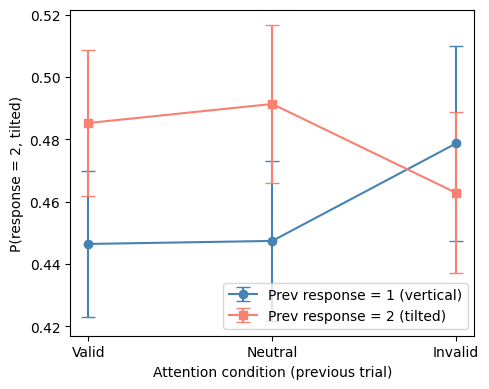

In [17]:
subj_resp2_prev = df_sd.groupby(['Subj_idx', 'prev_Attention', 'prev_Response'])['resp2'].mean().reset_index()
subj_resp2_prev['prev_Attention'] = subj_resp2_prev['prev_Attention'].astype(int)
subj_resp2_prev['prev_Response'] = subj_resp2_prev['prev_Response'].astype(int)

fig, ax = plt.subplots(figsize=(5, 4))
for prev_r, (label, marker, color) in prev_resp_styles.items():
    grp = subj_resp2_prev[subj_resp2_prev['prev_Response'] == prev_r]
    stats_grp = grp.groupby('prev_Attention')['resp2'].agg(['mean', 'sem'])
    ax.errorbar([1, 2, 3], stats_grp['mean'].values, yerr=stats_grp['sem'].values,
                marker=marker, color=color, capsize=5, linewidth=1.5,
                label=f'Prev response = {prev_r} ({label})')

ax.set_xticks([1, 2, 3])
ax.set_xticklabels(['Valid', 'Neutral', 'Invalid'])
ax.set_xlabel('Attention condition (previous trial)')
ax.set_ylabel('P(response = 2, tilted)')
ax.legend()
plt.tight_layout()
plt.show()

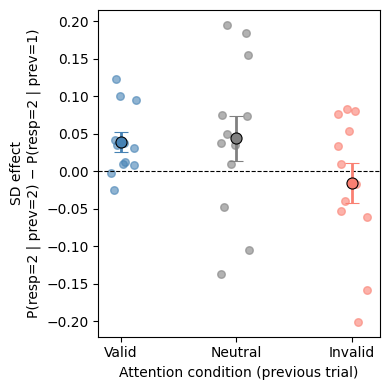

In [18]:
pivot_prev = subj_resp2_prev.pivot_table(
    index=['Subj_idx', 'prev_Attention'], columns='prev_Response', values='resp2'
).reset_index()
pivot_prev.columns.name = None
pivot_prev = pivot_prev.rename(columns={1: 'prev1', 2: 'prev2'})
pivot_prev['sd_effect'] = pivot_prev['prev2'] - pivot_prev['prev1']

fig, ax = plt.subplots(figsize=(4, 4))
for att in att_order:
    grp = pivot_prev[pivot_prev['prev_Attention'] == att]['sd_effect']
    x = att
    xs_jit = rng.uniform(x - jitter, x + jitter, size=len(grp))
    ax.scatter(xs_jit, grp.values, color=att_colors[att], alpha=0.6, s=30, zorder=2)
    ax.errorbar(x, grp.mean(), yerr=grp.sem(), color=att_colors[att],
                marker='o', markersize=8, capsize=5, linewidth=2, zorder=3,
                markeredgecolor='k', markeredgewidth=0.8)

ax.axhline(0, color='k', linestyle='--', linewidth=0.8)
ax.set_xticks(att_order)
ax.set_xticklabels(['Valid', 'Neutral', 'Invalid'])
ax.set_xlabel('Attention condition (previous trial)')
ax.set_ylabel('SD effect\nP(resp=2 | prev=2) − P(resp=2 | prev=1)')
plt.tight_layout()
plt.show()

In [19]:
print(f"{'Attention':<10} {'Mean SD':>10} {'SEM':>8} {'t':>8} {'p':>10}")
print("-" * 50)
for att, label in att_labels.items():
    grp = pivot_prev[pivot_prev['prev_Attention'] == att]['sd_effect']
    t, p = stats.ttest_1samp(grp, popmean=0)
    print(f"{label:<10} {grp.mean():>10.4f} {grp.sem():>8.4f} {t:>8.3f} {p:>10.4f}")

Attention     Mean SD      SEM        t          p
--------------------------------------------------
Valid          0.0388   0.0130    2.981     0.0125
Neutral        0.0440   0.0303    1.451     0.1747
Invalid       -0.0159   0.0267   -0.595     0.5639


## Serial dependence for choice as a function of confidence

Below we examine how the serial dependence effect varies with confidence, first using confidence on the current trial, then confidence on the previous trial.

In [35]:
# Identify subjects with data in all confidence x prev_response cells
_counts = df_sd.groupby(['Subj_idx', 'Confidence', 'prev_Response'])['resp2'].count().reset_index()
_pivot = _counts.pivot_table(index='Subj_idx', columns=['Confidence', 'prev_Response'], values='resp2')
complete_subjects = _pivot.dropna().index.tolist()
print(f"Complete subjects ({len(complete_subjects)}): {complete_subjects}")

df_sd_conf = df_sd[df_sd['Subj_idx'].isin(complete_subjects)]

Complete subjects (9): [1, 2, 3, 4, 6, 7, 8, 11, 12]


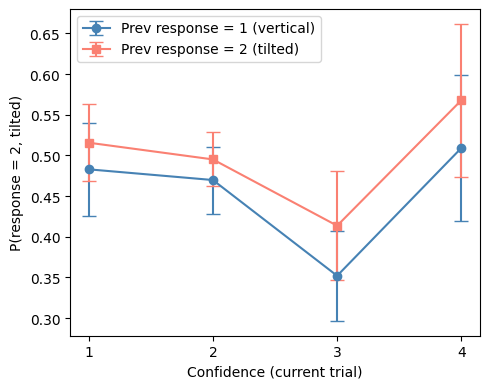

In [36]:
conf_order = [1, 2, 3, 4]

subj_resp2_conf = df_sd_conf.groupby(['Subj_idx', 'Confidence', 'prev_Response'])['resp2'].mean().reset_index()
subj_resp2_conf['Confidence'] = subj_resp2_conf['Confidence'].astype(int)

fig, ax = plt.subplots(figsize=(5, 4))
for prev_r, (label, marker, color) in prev_resp_styles.items():
    grp = subj_resp2_conf[subj_resp2_conf['prev_Response'] == prev_r]
    stats_grp = grp.groupby('Confidence')['resp2'].agg(['mean', 'sem'])
    ax.errorbar(conf_order, stats_grp['mean'].values, yerr=stats_grp['sem'].values,
                marker=marker, color=color, capsize=5, linewidth=1.5,
                label=f'Prev response = {prev_r} ({label})')

ax.set_xticks(conf_order)
ax.set_xlabel('Confidence (current trial)')
ax.set_ylabel('P(response = 2, tilted)')
ax.legend()
plt.tight_layout()
plt.show()

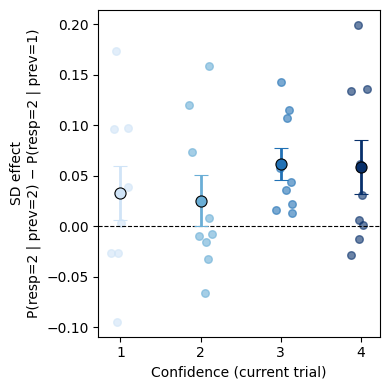

In [37]:
pivot_conf = subj_resp2_conf.pivot_table(
    index=['Subj_idx', 'Confidence'], columns='prev_Response', values='resp2'
).reset_index()
pivot_conf.columns.name = None
pivot_conf = pivot_conf.rename(columns={1: 'prev1', 2: 'prev2'})
pivot_conf['sd_effect'] = pivot_conf['prev2'] - pivot_conf['prev1']

conf_colors = {1: '#d0e4f7', 2: '#6aaed6', 3: '#2171b5', 4: '#08306b'}

fig, ax = plt.subplots(figsize=(4, 4))
for conf in conf_order:
    grp = pivot_conf[pivot_conf['Confidence'] == conf]['sd_effect']
    xs_jit = rng.uniform(conf - jitter, conf + jitter, size=len(grp))
    ax.scatter(xs_jit, grp.values, color=conf_colors[conf], alpha=0.6, s=30, zorder=2)
    ax.errorbar(conf, grp.mean(), yerr=grp.sem(), color=conf_colors[conf],
                marker='o', markersize=8, capsize=5, linewidth=2, zorder=3,
                markeredgecolor='k', markeredgewidth=0.8)

ax.axhline(0, color='k', linestyle='--', linewidth=0.8)
ax.set_xticks(conf_order)
ax.set_xlabel('Confidence (current trial)')
ax.set_ylabel('SD effect\nP(resp=2 | prev=2) − P(resp=2 | prev=1)')
plt.tight_layout()
plt.show()

In [38]:
print(f"{'Confidence':<12} {'Mean SD':>10} {'SEM':>8} {'t':>8} {'p':>10}")
print("-" * 52)
for conf in conf_order:
    grp = pivot_conf[pivot_conf['Confidence'] == conf]['sd_effect']
    t, p = stats.ttest_1samp(grp, popmean=0)
    print(f"{conf:<12} {grp.mean():>10.4f} {grp.sem():>8.4f} {t:>8.3f} {p:>10.4f}")

Confidence      Mean SD      SEM        t          p
----------------------------------------------------
1                0.0327   0.0269    1.216     0.2588
2                0.0253   0.0251    1.012     0.3413
3                0.0616   0.0161    3.833     0.0050
4                0.0587   0.0265    2.212     0.0579


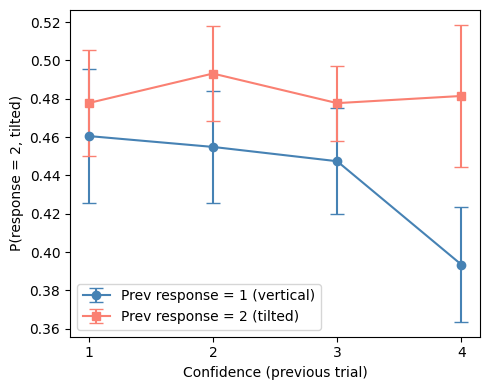

In [39]:
subj_resp2_pconf = df_sd_conf.groupby(['Subj_idx', 'prev_Confidence', 'prev_Response'])['resp2'].mean().reset_index()
subj_resp2_pconf['prev_Confidence'] = subj_resp2_pconf['prev_Confidence'].astype(int)

fig, ax = plt.subplots(figsize=(5, 4))
for prev_r, (label, marker, color) in prev_resp_styles.items():
    grp = subj_resp2_pconf[subj_resp2_pconf['prev_Response'] == prev_r]
    stats_grp = grp.groupby('prev_Confidence')['resp2'].agg(['mean', 'sem'])
    ax.errorbar(conf_order, stats_grp['mean'].values, yerr=stats_grp['sem'].values,
                marker=marker, color=color, capsize=5, linewidth=1.5,
                label=f'Prev response = {prev_r} ({label})')

ax.set_xticks(conf_order)
ax.set_xlabel('Confidence (previous trial)')
ax.set_ylabel('P(response = 2, tilted)')
ax.legend()
plt.tight_layout()
plt.show()

In [53]:
subj_resp2_pconf

,Subj_idx,prev_Confidence,prev_Response,resp2
0,1,1,1,0.428571
1,1,1,2,0.585859
2,1,2,1,0.403409
3,1,2,2,0.437642
4,1,3,1,0.390995
...,...,...,...,...
67,12,2,2,0.511475
68,12,3,1,0.464387
69,12,3,2,0.487805
70,12,4,1,0.340426


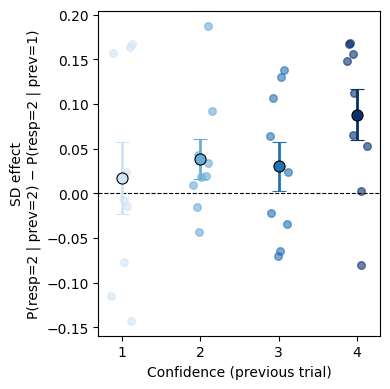

In [40]:
pivot_pconf = subj_resp2_pconf.pivot_table(
    index=['Subj_idx', 'prev_Confidence'], columns='prev_Response', values='resp2'
).reset_index()
pivot_pconf.columns.name = None
pivot_pconf = pivot_pconf.rename(columns={1: 'prev1', 2: 'prev2'})
pivot_pconf['sd_effect'] = pivot_pconf['prev2'] - pivot_pconf['prev1']

fig, ax = plt.subplots(figsize=(4, 4))
for conf in conf_order:
    grp = pivot_pconf[pivot_pconf['prev_Confidence'] == conf]['sd_effect']
    xs_jit = rng.uniform(conf - jitter, conf + jitter, size=len(grp))
    ax.scatter(xs_jit, grp.values, color=conf_colors[conf], alpha=0.6, s=30, zorder=2)
    ax.errorbar(conf, grp.mean(), yerr=grp.sem(), color=conf_colors[conf],
                marker='o', markersize=8, capsize=5, linewidth=2, zorder=3,
                markeredgecolor='k', markeredgewidth=0.8)

ax.axhline(0, color='k', linestyle='--', linewidth=0.8)
ax.set_xticks(conf_order)
ax.set_xlabel('Confidence (previous trial)')
ax.set_ylabel('SD effect\nP(resp=2 | prev=2) − P(resp=2 | prev=1)')
plt.tight_layout()
plt.show()

In [41]:
print(f"{'Confidence':<12} {'Mean SD':>10} {'SEM':>8} {'t':>8} {'p':>10}")
print("-" * 52)
for conf in conf_order:
    grp = pivot_pconf[pivot_pconf['prev_Confidence'] == conf]['sd_effect']
    t, p = stats.ttest_1samp(grp, popmean=0)
    print(f"{conf:<12} {grp.mean():>10.4f} {grp.sem():>8.4f} {t:>8.3f} {p:>10.4f}")

Confidence      Mean SD      SEM        t          p
----------------------------------------------------
1                0.0172   0.0404    0.427     0.6808
2                0.0383   0.0225    1.705     0.1265
3                0.0303   0.0275    1.101     0.3029
4                0.0880   0.0286    3.078     0.0152


## Check if any subjects have missing data

Some subjects may be missing data in the cells relevant for the SD analyses. A particular possibility for the confidence analyses as some subjects rarely report high confidence.

In [42]:
# Check completeness for attention analysis (3 attention levels x 2 prev_response = 6 cells)
_att_counts = df_sd.groupby(['Subj_idx', 'Attention', 'prev_Response'])['resp2'].count().reset_index()
_att_pivot = _att_counts.pivot_table(index='Subj_idx', columns=['Attention', 'prev_Response'], values='resp2')
print("N trials per subject x attention x prev_response (NaN = missing cell):")
print(_att_pivot.to_string())
missing = _att_pivot[_att_pivot.isnull().any(axis=1)].index.tolist()
print(f"\nSubjects with missing cells: {missing if missing else 'None'}")

N trials per subject x attention x prev_response (NaN = missing cell):
Attention          1             2             3       
prev_Response      1      2      1      2      1      2
Subj_idx                                               
1              824.0  647.0  192.0  160.0  206.0  130.0
2              847.0  573.0  228.0  146.0  234.0  131.0
3              643.0  537.0  139.0  143.0  166.0   99.0
4              860.0  597.0  195.0  167.0  205.0  135.0
5              923.0  585.0  206.0  136.0  178.0  131.0
6              671.0  481.0  191.0  122.0  162.0  100.0
7              834.0  610.0  219.0  135.0  205.0  156.0
8              568.0  849.0  137.0  247.0  146.0  212.0
9              529.0  823.0  119.0  211.0  125.0  208.0
10             700.0  561.0  179.0  141.0  167.0  123.0
11             716.0  715.0  173.0  197.0  183.0  175.0
12             711.0  722.0  184.0  170.0  191.0  181.0

Subjects with missing cells: None


In [32]:
# Check N subjects contributing to each confidence x prev_response cell
cell_counts = subj_resp2_conf.groupby(['Confidence', 'prev_Response'])['Subj_idx'].count().unstack()
print("N subjects per cell (confidence x prev_response):")
print(cell_counts)

# Check N subjects in SD effect pivot (requires both prev_response conditions)
print("\nN subjects in SD effect per confidence level:")
print(pivot_conf.groupby('Confidence')['sd_effect'].count())

N subjects per cell (confidence x prev_response):
prev_Response   1   2
Confidence           
1              12  11
2              12  12
3              11  12
4              10  11

N subjects in SD effect per confidence level:
Confidence
1    11
2    12
3    11
4    10
Name: sd_effect, dtype: int64


In [33]:
# Subjects with data in all 8 cells (4 confidence levels x 2 prev_response values)
n_expected = len(conf_order) * 2
subj_cell_counts = subj_resp2_conf.groupby('Subj_idx').size()
complete_subjects = subj_cell_counts[subj_cell_counts == n_expected].index.tolist()
print(f"Expected cells per subject: {n_expected}")
print(f"Cells per subject:\n{subj_cell_counts.to_string()}")
print(f"\nSubjects with complete data: {complete_subjects}")

Expected cells per subject: 8
Cells per subject:
Subj_idx
1     8
2     8
3     8
4     8
5     7
6     8
7     8
8     8
9     5
10    7
11    8
12    8

Subjects with complete data: [1, 2, 3, 4, 6, 7, 8, 11, 12]


## Logistic regression: effect of current attention and confidence on serial dependence

We fit a per-subject logistic regression predicting the current response (resp = 2, "tilted"), then test group-level coefficients against zero with one-sample t-tests.

**Model:**

logit P(resp = 2) = β₀ + β₁·|Orientation| + β₂·prev_Response + β₃·Attention + β₄·Confidence + β₅·(prev_Response × Attention) + β₆·(prev_Response × Confidence)

**Predictor coding:**
- `|Orientation|`: mean-centered — controls for current evidence strength
- `prev_Response`: −0.5 (vertical) / +0.5 (tilted)
- `Attention`: linear contrast — Valid(+1), Neutral(0), Invalid(-1); higher = more attended
- `Confidence`: mean-centered (1–4 scale)

β₅ tests whether SD changes linearly across the Valid → Neutral → Invalid attention gradient; β₆ tests whether SD scales with current confidence.

In [45]:
import statsmodels.api as sm

d = df_sd.copy()
d['abs_Orientation_c'] = d['Orientation'].abs()
d['abs_Orientation_c'] -= d['abs_Orientation_c'].mean()
d['prev_Response_c'] = d['prev_Response'] - 1.5           # -0.5 / +0.5
d['Confidence_c']    = d['Confidence'] - d['Confidence'].mean()
d['Att_linear']      = (d['Attention'] - 2)*(-1)                 # Valid=+1, Neutral=0, Invalid=-1
d['prevR_x_Att']     = d['prev_Response_c'] * d['Att_linear']
d['prevR_x_Conf']    = d['prev_Response_c'] * d['Confidence_c']

predictors = ['abs_Orientation_c', 'prev_Response_c', 'Att_linear',
              'Confidence_c', 'prevR_x_Att', 'prevR_x_Conf']

coef_rows = []
for subj in sorted(d['Subj_idx'].unique()):
    subj_df = d[d['Subj_idx'] == subj]
    X = sm.add_constant(subj_df[predictors])
    model = sm.Logit(subj_df['resp2'], X).fit(disp=0)
    coef_rows.append(model.params)

coefs_df = pd.DataFrame(coef_rows, index=sorted(d['Subj_idx'].unique()))
coefs_df.index.name = 'Subj_idx'

print(f"{'Predictor':<22} {'Mean β':>10} {'SEM':>8} {'t':>8} {'p':>10}")
print("-" * 62)
for col in predictors:
    t, p = stats.ttest_1samp(coefs_df[col], popmean=0)
    print(f"{col:<22} {coefs_df[col].mean():>10.4f} {coefs_df[col].sem():>8.4f} {t:>8.3f} {p:>10.4f}")

Predictor                  Mean β      SEM        t          p
--------------------------------------------------------------
abs_Orientation_c          0.2705   0.0237   11.402     0.0000
prev_Response_c            0.0681   0.0616    1.106     0.2925
Att_linear                -0.1404   0.0897   -1.565     0.1459
Confidence_c              -0.1660   0.2922   -0.568     0.5814
prevR_x_Att                0.0521   0.0502    1.036     0.3224
prevR_x_Conf               0.0219   0.0399    0.550     0.5931


## Logistic regression: effect of previous attention and confidence on serial dependence

Same model structure, but attention and confidence now refer to the **previous trial**, testing whether the quality of encoding of the previous stimulus modulates how strongly it influences the current response.

**Model:**

logit P(resp = 2) = β₀ + β₁·|Orientation| + β₂·prev_Response + β₃·prev_Attention + β₄·prev_Confidence + β₅·(prev_Response × prev_Attention) + β₆·(prev_Response × prev_Confidence)

**Predictor coding:**
- `|Orientation|`: mean-centered (current trial evidence control)
- `prev_Response`: −0.5 (vertical) / +0.5 (tilted)
- `prev_Attention`: linear contrast — Valid(+1), Neutral(0), Invalid(−1)
- `prev_Confidence`: mean-centered (1–4 scale)

β₅ tests whether SD is stronger when the previous stimulus was better attended; β₆ tests whether SD scales with confidence on the previous trial.

In [48]:
d2 = df_sd.copy()
d2['abs_Orientation_c']  = d2['Orientation'].abs()
d2['abs_Orientation_c'] -= d2['abs_Orientation_c'].mean()
d2['prev_Response_c']    = d2['prev_Response'] - 1.5
d2['prev_Att_linear']    = d2['prev_Attention'] - 2          # Valid=+1, Neutral=0, Invalid=-1 (after *-1 below)
d2['prev_Att_linear']   *= -1
d2['prev_Conf_c']        = d2['prev_Confidence'] - d2['prev_Confidence'].mean()
d2['prevR_x_prevAtt']    = d2['prev_Response_c'] * d2['prev_Att_linear']
d2['prevR_x_prevConf']   = d2['prev_Response_c'] * d2['prev_Conf_c']

predictors2 = ['abs_Orientation_c', 'prev_Response_c', 'prev_Att_linear',
               'prev_Conf_c', 'prevR_x_prevAtt', 'prevR_x_prevConf']

coef_rows2 = []
for subj in sorted(d2['Subj_idx'].unique()):
    subj_df = d2[d2['Subj_idx'] == subj]
    X = sm.add_constant(subj_df[predictors2])
    model = sm.Logit(subj_df['resp2'], X).fit(disp=0)
    coef_rows2.append(model.params)

coefs_df2 = pd.DataFrame(coef_rows2, index=sorted(d2['Subj_idx'].unique()))
coefs_df2.index.name = 'Subj_idx'

print(f"{'Predictor':<22} {'Mean β':>10} {'SEM':>8} {'t':>8} {'p':>10}")
print("-" * 62)
for col in predictors2:
    t, p = stats.ttest_1samp(coefs_df2[col], popmean=0)
    print(f"{col:<22} {coefs_df2[col].mean():>10.4f} {coefs_df2[col].sem():>8.4f} {t:>8.3f} {p:>10.4f}")

Predictor                  Mean β      SEM        t          p
--------------------------------------------------------------
abs_Orientation_c          0.2590   0.0211   12.295     0.0000
prev_Response_c            0.1264   0.1003    1.260     0.2336
prev_Att_linear           -0.0222   0.0262   -0.845     0.4159
prev_Conf_c               -0.0499   0.0293   -1.699     0.1175
prevR_x_prevAtt            0.0932   0.0474    1.965     0.0752
prevR_x_prevConf           0.1134   0.0572    1.981     0.0732


### Partial effects of previous attention and confidence on serial dependence

Because the full model above includes both interaction terms simultaneously, each coefficient already represents a partial effect — the modulation of SD by one variable with the other held constant. The cells below extract and visualize these partial coefficients directly from `coefs_df2`.

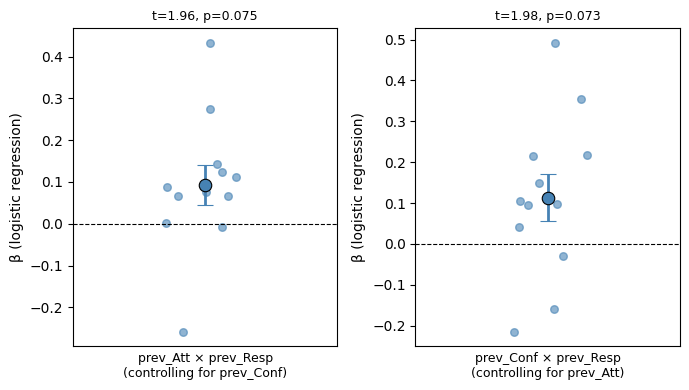

In [49]:
partial_terms = {
    'prevR_x_prevAtt':  'prev_Att × prev_Resp\n(controlling for prev_Conf)',
    'prevR_x_prevConf': 'prev_Conf × prev_Resp\n(controlling for prev_Att)',
}

fig, axes = plt.subplots(1, 2, figsize=(7, 4), sharey=False)

for ax, (col, label) in zip(axes, partial_terms.items()):
    vals = coefs_df2[col]
    t, p = stats.ttest_1samp(vals, popmean=0)

    xs_jit = rng.uniform(0.85, 1.15, size=len(vals))
    ax.scatter(xs_jit, vals, color='steelblue', alpha=0.6, s=30, zorder=2)
    ax.errorbar(1, vals.mean(), yerr=vals.sem(), color='steelblue',
                marker='o', markersize=9, capsize=6, linewidth=2, zorder=3,
                markeredgecolor='k', markeredgewidth=0.8)
    ax.axhline(0, color='k', linestyle='--', linewidth=0.8)
    ax.set_xlim(0.5, 1.5)
    ax.set_xticks([])
    ax.set_xlabel(label, fontsize=9)
    ax.set_ylabel('β (logistic regression)')
    ax.set_title(f't={t:.2f}, p={p:.3f}', fontsize=9)

plt.tight_layout()
plt.show()

In [51]:
def residualize(y, x):
    """Regress y on x (with intercept) and return residuals."""
    X = np.column_stack([np.ones(len(x)), x])
    betas, _, _, _ = np.linalg.lstsq(X, y, rcond=None)
    return y - X @ betas

# Build orthogonalized interaction terms per subject
d3 = d2.copy()
conf_resid_all = np.full(len(d3), np.nan)
att_resid_all  = np.full(len(d3), np.nan)

for subj in sorted(d3['Subj_idx'].unique()):
    idx = d3['Subj_idx'] == subj
    att  = d3.loc[idx, 'prev_Att_linear'].values
    conf = d3.loc[idx, 'prev_Conf_c'].values
    conf_resid_all[idx] = residualize(conf, att)   # conf ⊥ att
    att_resid_all[idx]  = residualize(att,  conf)  # att  ⊥ conf

d3['prev_Conf_orth'] = conf_resid_all   # variance in confidence not shared with attention
d3['prev_Att_orth']  = att_resid_all    # variance in attention not shared with confidence
d3['prevR_x_ConfOrth'] = d3['prev_Response_c'] * d3['prev_Conf_orth']
d3['prevR_x_AttOrth']  = d3['prev_Response_c'] * d3['prev_Att_orth']

predictors3 = ['abs_Orientation_c', 'prev_Response_c', 'prev_Att_orth',
               'prev_Conf_orth', 'prevR_x_AttOrth', 'prevR_x_ConfOrth']

coef_rows3 = []
for subj in sorted(d3['Subj_idx'].unique()):
    subj_df = d3[d3['Subj_idx'] == subj]
    X = sm.add_constant(subj_df[predictors3])
    model = sm.Logit(subj_df['resp2'], X).fit(disp=0)
    coef_rows3.append(model.params)

coefs_df3 = pd.DataFrame(coef_rows3, index=sorted(d3['Subj_idx'].unique()))
coefs_df3.index.name = 'Subj_idx'

print(f"{'Predictor':<25} {'Mean β':>10} {'SEM':>8} {'t':>8} {'p':>10}")
print("-" * 65)
for col in predictors3:
    t, p = stats.ttest_1samp(coefs_df3[col], popmean=0)
    print(f"{col:<25} {coefs_df3[col].mean():>10.4f} {coefs_df3[col].sem():>8.4f} {t:>8.3f} {p:>10.4f}")

Predictor                     Mean β      SEM        t          p
-----------------------------------------------------------------
abs_Orientation_c             0.2590   0.0211   12.295     0.0000
prev_Response_c               0.1051   0.0703    1.494     0.1634
prev_Att_orth                -0.0300   0.0304   -0.989     0.3441
prev_Conf_orth               -0.0609   0.0290   -2.098     0.0598
prevR_x_AttOrth               0.1557   0.0590    2.636     0.0232
prevR_x_ConfOrth              0.1480   0.0613    2.417     0.0342


In [52]:
# Same orthogonalized model for current attention and confidence
d4 = d.copy()
conf_resid_curr = np.full(len(d4), np.nan)
att_resid_curr  = np.full(len(d4), np.nan)

for subj in sorted(d4['Subj_idx'].unique()):
    idx  = d4['Subj_idx'] == subj
    att  = d4.loc[idx, 'Att_linear'].values
    conf = d4.loc[idx, 'Confidence_c'].values
    conf_resid_curr[idx] = residualize(conf, att)
    att_resid_curr[idx]  = residualize(att,  conf)

d4['Conf_orth'] = conf_resid_curr
d4['Att_orth']  = att_resid_curr
d4['prevR_x_ConfOrth'] = d4['prev_Response_c'] * d4['Conf_orth']
d4['prevR_x_AttOrth']  = d4['prev_Response_c'] * d4['Att_orth']

predictors4 = ['abs_Orientation_c', 'prev_Response_c', 'Att_orth',
               'Conf_orth', 'prevR_x_AttOrth', 'prevR_x_ConfOrth']

coef_rows4 = []
for subj in sorted(d4['Subj_idx'].unique()):
    subj_df = d4[d4['Subj_idx'] == subj]
    X = sm.add_constant(subj_df[predictors4])
    model = sm.Logit(subj_df['resp2'], X).fit(disp=0)
    coef_rows4.append(model.params)

coefs_df4 = pd.DataFrame(coef_rows4, index=sorted(d4['Subj_idx'].unique()))
coefs_df4.index.name = 'Subj_idx'

print(f"{'Predictor':<25} {'Mean β':>10} {'SEM':>8} {'t':>8} {'p':>10}")
print("-" * 65)
for col in predictors4:
    t, p = stats.ttest_1samp(coefs_df4[col], popmean=0)
    print(f"{col:<25} {coefs_df4[col].mean():>10.4f} {coefs_df4[col].sem():>8.4f} {t:>8.3f} {p:>10.4f}")

Predictor                     Mean β      SEM        t          p
-----------------------------------------------------------------
abs_Orientation_c             0.2705   0.0237   11.402     0.0000
prev_Response_c               0.1229   0.0601    2.044     0.0656
Att_orth                     -0.3652   0.1265   -2.888     0.0148
Conf_orth                    -0.2609   0.3063   -0.852     0.4125
prevR_x_AttOrth               0.0934   0.0563    1.658     0.1255
prevR_x_ConfOrth              0.0450   0.0463    0.972     0.3521


## ANOVAs

In [60]:
from statsmodels.stats.anova import AnovaRM

# subj_resp2 already has per-subject P(resp=2) by current Attention x prev_Response
anova_data = subj_resp2.rename(columns={'resp2': 'P_resp2'})

rm = AnovaRM(data=anova_data, depvar='P_resp2', subject='Subj_idx',
             within=['Attention', 'prev_Response'])
result = rm.fit()
print("=== Current attention x prev_Response ===")
print(result.summary())

=== Current attention x prev_Response ===
                        Anova
                        F Value Num DF  Den DF Pr > F
-----------------------------------------------------
Attention                3.4011 2.0000 22.0000 0.0516
prev_Response            1.5030 1.0000 11.0000 0.2458
Attention:prev_Response  3.8592 2.0000 22.0000 0.0366



In [56]:
table = anova_data.pivot_table(index='Subj_idx', columns=['Attention', 'prev_Response'], values='P_resp2')
table.columns = [f'Att={att_labels[a]}, PrevResp={r}' for a, r in table.columns]
table.loc['Mean'] = table.mean()
table.round(3)

,"Att=Valid, PrevResp=1","Att=Valid, PrevResp=2","Att=Neutral, PrevResp=1","Att=Neutral, PrevResp=2","Att=Invalid, PrevResp=1","Att=Invalid, PrevResp=2"
Subj_idx,,,,,,
1,0.417,0.498,0.312,0.481,0.388,0.423
2,0.306,0.361,0.487,0.445,0.568,0.580
3,0.404,0.521,0.381,0.497,0.434,0.434
4,0.356,0.511,0.354,0.491,0.400,0.407
5,0.398,0.373,0.374,0.397,0.449,0.427
6,0.371,0.339,0.524,0.369,0.593,0.500
7,0.380,0.430,0.402,0.378,0.512,0.500
8,0.523,0.544,0.723,0.713,0.795,0.745
9,0.522,0.550,0.975,0.943,0.584,0.606


In [59]:
anova_data_prev = subj_resp2_prev.rename(columns={'resp2': 'P_resp2'})

rm_prev = AnovaRM(data=anova_data_prev, depvar='P_resp2', subject='Subj_idx',
                  within=['prev_Attention', 'prev_Response'])
result_prev = rm_prev.fit()
print("=== Previous attention x prev_Response ===")
print(result_prev.summary())

=== Previous attention x prev_Response ===
                          Anova
                             F Value Num DF  Den DF Pr > F
----------------------------------------------------------
prev_Attention                0.1063 2.0000 22.0000 0.8996
prev_Response                 1.1701 1.0000 11.0000 0.3025
prev_Attention:prev_Response  4.2015 2.0000 22.0000 0.0285



In [58]:
# Current confidence — subj_resp2_conf already filtered to complete_subjects
anova_conf = subj_resp2_conf.rename(columns={'resp2': 'P_resp2'})
rm_conf = AnovaRM(data=anova_conf, depvar='P_resp2', subject='Subj_idx',
                  within=['Confidence', 'prev_Response'])
print("=== Current confidence x prev_Response ===")
print(rm_conf.fit().summary())

# Previous confidence — subj_resp2_pconf also filtered to complete_subjects
anova_pconf = subj_resp2_pconf.rename(columns={'resp2': 'P_resp2'})
rm_pconf = AnovaRM(data=anova_pconf, depvar='P_resp2', subject='Subj_idx',
                   within=['prev_Confidence', 'prev_Response'])
print("=== Previous confidence x prev_Response ===")
print(rm_pconf.fit().summary())

=== Current confidence x prev_Response ===
                        Anova
                         F Value Num DF  Den DF Pr > F
------------------------------------------------------
Confidence                1.1614 3.0000 24.0000 0.3450
prev_Response             5.9134 1.0000  8.0000 0.0411
Confidence:prev_Response  1.0285 3.0000 24.0000 0.3976

=== Previous confidence x prev_Response ===
                           Anova
                              F Value Num DF  Den DF Pr > F
-----------------------------------------------------------
prev_Confidence                2.0826 3.0000 24.0000 0.1291
prev_Response                  3.3892 1.0000  8.0000 0.1029
prev_Confidence:prev_Response  1.9406 3.0000 24.0000 0.1500

